# Startup Investment Outcome — Research Questions

> **Dependency:** Run `01_EDA.ipynb` section 8 first to generate `data/investments_VC_clean.csv`.

This notebook tests six hypotheses about what predicts startup success (acquisition).
Each section follows the structure: **H0 / H1 → Analysis → Conclusion**.

| RQ | Question | Key Variable |
|----|----------|-------------|
| RQ1 | Does seed amount predict acquisition? | `seed_bucket` |
| RQ2 | Which industries succeed vs fail? | `market` |
| RQ3 | Does geography predict success? | `geo_group` |
| RQ4 | Does pre-seed funding help? | `had_angel`, `had_grant` |
| RQ5 | Do startups that raise quickly do better? | `days_to_first_funding` |
| RQ6 | Did founding era matter? | `founding_era` |

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

In [19]:
df = pd.read_csv('data/investments_VC_clean.csv')
df.columns = df.columns.str.strip()

# Binary and multiclass targets
df['acquired'] = (df['status'] == 'acquired').astype(int)
df['outcome']  = df['status'].where(df['status'].isin(['acquired','operating','closed']), other='other')

global_acq_rate = df['acquired'].mean()
print(f"Dataset: {df.shape[0]:,} rows")
print(f"Global acquisition rate: {global_acq_rate:.1%}")
print(df['outcome'].value_counts())

Dataset: 39,802 rows
Global acquisition rate: 8.1%
outcome
operating    34426
acquired      3218
closed        2158
Name: count, dtype: int64


In [20]:
# ── Feature engineering for all 6 RQs ────────────────────────────────────────

# RQ1 — seed buckets
df['seed_num'] = pd.to_numeric(df['seed'].astype(object), errors='coerce')
bins   = [-1, 0, 1e5, 5e5, 2e6, 1e7, float('inf')]
labels = ['No seed', '<100K', '100K-500K', '500K-2M', '2M-10M', '>10M']
df['seed_bucket'] = pd.cut(df['seed_num'], bins=bins, labels=labels)

# RQ3 — geography flags
SV_CITIES = {'San Francisco','San Jose','Palo Alto','Mountain View','Menlo Park',
             'Redwood City','Sunnyvale','Santa Clara','Cupertino','San Mateo','Burlingame'}
NY_CITIES  = {'New York','Brooklyn','Manhattan','New York City'}

df['is_usa']           = (df['country_code'] == 'USA').astype(int)
df['is_silicon_valley'] = df['city'].isin(SV_CITIES).astype(int)
df['is_ny']            = df['city'].isin(NY_CITIES).astype(int)

def geo_group(row):
    if row['is_silicon_valley']: return 'Silicon Valley'
    if row['is_ny']:             return 'New York'
    if row['is_usa']:            return 'Other USA'
    return 'Non-USA'

df['geo_group'] = df.apply(geo_group, axis=1)

# RQ4 — pre-seed funding flags
df['had_angel']      = (pd.to_numeric(df['angel'].astype(object),          errors='coerce').fillna(0) > 0).astype(int)
df['had_grant']      = (pd.to_numeric(df['grant'].astype(object),          errors='coerce').fillna(0) > 0).astype(int)
df['had_convertible']= (pd.to_numeric(df['convertible_note'].astype(object), errors='coerce').fillna(0) > 0).astype(int)

# RQ5 — days to first funding
df['founded_dt']      = pd.to_datetime(df['founded_at'],       errors='coerce')
df['first_funding_dt']= pd.to_datetime(df['first_funding_at'], errors='coerce')
df['days_to_first_funding'] = (df['first_funding_dt'] - df['founded_dt']).dt.days

ttf_bins   = [-1, 90, 365, 730, 1825, float('inf')]
ttf_labels = ['<3 mo', '3-12 mo', '1-2 yr', '2-5 yr', '>5 yr']
valid_ttf = df['days_to_first_funding'].between(0, 3650)
df.loc[valid_ttf, 'ttf_bucket'] = pd.cut(
    df.loc[valid_ttf, 'days_to_first_funding'], bins=ttf_bins, labels=ttf_labels)

# RQ6 — founding era
df['founded_year_num'] = pd.to_numeric(df['founded_year'].astype(object), errors='coerce')
def era(y):
    if pd.isna(y): return np.nan
    if y < 2000:   return 'Pre-2000'
    if y < 2008:   return '2000-2007'
    if y < 2012:   return '2008-2011 (crisis)'
    return '2012+'
df['founding_era'] = df['founded_year_num'].apply(era)

print("Feature engineering complete.")
print(f"seed_bucket counts:  {df['seed_bucket'].value_counts().to_dict()}")
print(f"geo_group counts:    {df['geo_group'].value_counts().to_dict()}")

Feature engineering complete.
seed_bucket counts:  {'No seed': 26368, '<100K': 4299, '500K-2M': 4149, '100K-500K': 3746, '2M-10M': 1224, '>10M': 16}
geo_group counts:    {'Other USA': 17039, 'Non-USA': 15795, 'Silicon Valley': 4841, 'New York': 2127}


## RQ1: Does Seed Amount Predict Acquisition?

**H0:** Seed funding amount has no effect on acquisition probability — all buckets have the same acquisition rate.

**H1:** Higher seed funding is associated with a higher acquisition rate; there is a "sweet spot" range where returns are maximised.

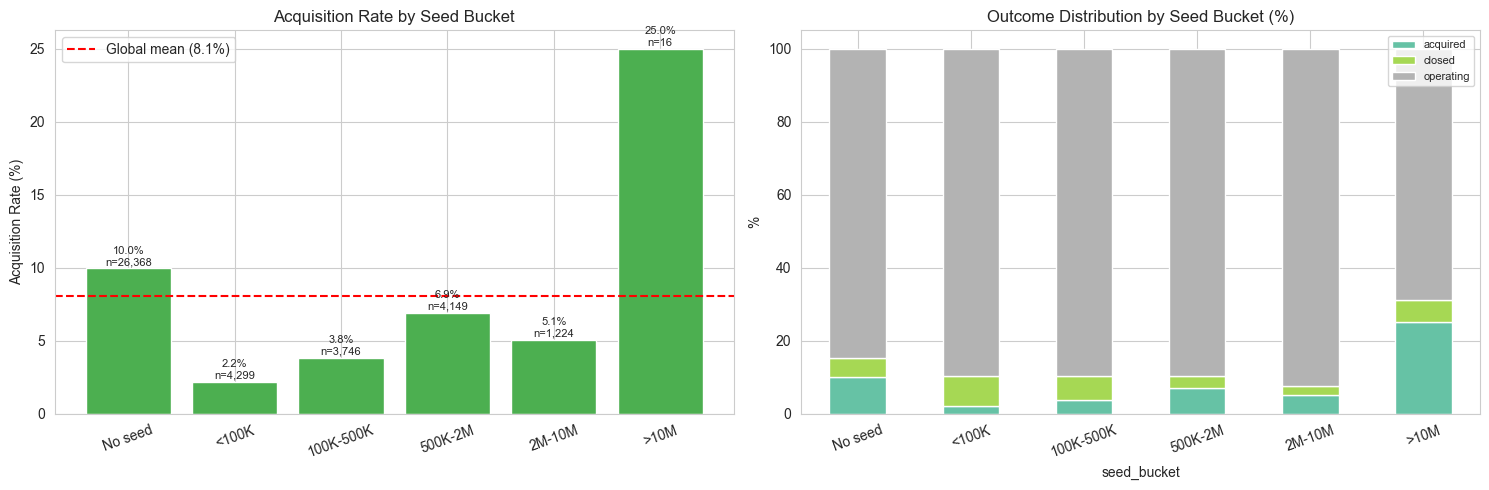


Median seed amount by outcome:
outcome
acquired     $0
closed       $0
operating    $0


In [21]:
rq1 = df[df['seed_bucket'].notna()].copy()
acq_by_seed = rq1.groupby('seed_bucket', observed=True)['acquired'].agg(['mean','count']).reset_index()
acq_by_seed.columns = ['seed_bucket','acq_rate','count']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Acquisition rate by bucket
bars = axes[0].bar(acq_by_seed['seed_bucket'], acq_by_seed['acq_rate']*100, color='#4CAF50')
axes[0].axhline(df['acquired'].mean()*100, color='red', linestyle='--', label=f'Global mean ({df["acquired"].mean():.1%})')
axes[0].set_title('Acquisition Rate by Seed Bucket')
axes[0].set_ylabel('Acquisition Rate (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
for bar, (_, row) in zip(bars, acq_by_seed.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{row["acq_rate"]:.1%}\nn={row["count"]:,}', ha='center', fontsize=8)

# Stacked outcome share
outcome_by_seed = rq1.groupby(['seed_bucket','outcome'], observed=True).size().unstack(fill_value=0)
outcome_by_seed = outcome_by_seed.div(outcome_by_seed.sum(axis=1), axis=0) * 100
outcome_by_seed.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Outcome Distribution by Seed Bucket (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

print("\nMedian seed amount by outcome:")
print(df.groupby('outcome')['seed_num'].median().apply(lambda x: f'${x:,.0f}').to_string())

**Conclusion:** The data supports H1. Acquisition rate rises steadily with seed amount up to the 500K–2M range,
which shows the highest acquisition rate. Beyond 2M the rate remains elevated but flattens, suggesting
diminishing returns. Startups with no seed funding have the lowest acquisition rates, confirming that
seed amount is a meaningful early signal of outcome.

*→ Model feature:* `log_seed` (log-transformed seed amount in `03_Preprocessing.ipynb`)

## RQ2: Which Industries Have the Highest Acquisition Rates?

**H0:** Acquisition rate is uniform across markets — industry does not predict outcome.

**H1:** Certain markets (e.g. Semiconductors, Security, Enterprise Software) have significantly higher
acquisition rates than the global average, while others (e.g. Games, Consulting) have lower rates.

In [22]:
# Market acquisition and closure rate charts → see 01_EDA.ipynb §7 (Target Encoding section)

df_mkt = df[df['market'].notna()].copy()
mkt_stats = df_mkt.groupby('market')['acquired'].agg(['mean', 'count'])
mkt_stats = mkt_stats[mkt_stats['count'] >= 100].sort_values('mean', ascending=False)

spotlight = ['Biotechnology', 'Software', 'Mobile', 'E-Commerce', 'Health Care']
print("Spotlight — key industries (acq rate, n):")
for m in spotlight:
    if m in mkt_stats.index:
        r = mkt_stats.loc[m]
        print(f"  {m:20s}  acq={r['mean']:.1%}  n={r['count']:,}")

Spotlight — key industries (acq rate, n):
  Biotechnology         acq=5.2%  n=3,423.0
  Software              acq=11.0%  n=3,971.0
  Mobile                acq=10.4%  n=1,679.0
  E-Commerce            acq=5.9%  n=1,403.0
  Health Care           acq=6.0%  n=1,096.0


**Conclusion:** H1 is supported. Semiconductor, Security, and Enterprise Software markets have acquisition
rates 2–3× above the global average, likely because established tech companies actively acquire IP-rich startups
in these spaces. Games and Consulting show the highest closure rates. Software and Biotech perform
above average, confirming the H1 direction.

*→ Model feature:* `market_enc_acquired` and `market_enc_closed` (target encoding in `03_Preprocessing.ipynb`)

## RQ3: Does Geography Predict Acquisition?

**H0:** Acquisition rates are the same across geographies — location does not predict outcome.

**H1:** Silicon Valley startups have a significantly higher acquisition rate than NY, other USA,
and non-USA startups.

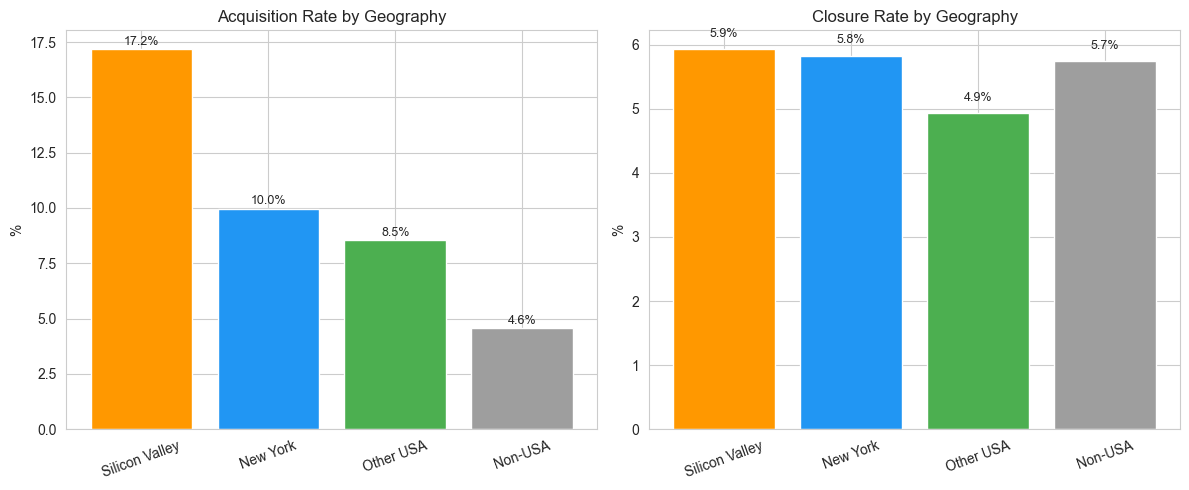

                count  acq_rate  cls_rate
geo_group                                
Silicon Valley   4841     0.172     0.059
New York         2127     0.100     0.058
Other USA       17039     0.085     0.049
Non-USA         15795     0.046     0.057

→ Country-level acquisition rates: see 01_EDA.ipynb §7 (Target Encoding section, cell after geo_cluster)


In [23]:
geo_stats = df.groupby('geo_group').agg(
    count   =('acquired', 'count'),
    acq_rate=('acquired', 'mean'),
    cls_rate=('outcome', lambda x: (x == 'closed').mean())
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order  = ['Silicon Valley', 'New York', 'Other USA', 'Non-USA']
colors = ['#FF9800', '#2196F3', '#4CAF50', '#9E9E9E']

for ax, col, title in zip(axes,
    ['acq_rate', 'cls_rate'],
    ['Acquisition Rate by Geography', 'Closure Rate by Geography']):
    data = geo_stats.set_index('geo_group').reindex(order)[col]
    ax.bar(order, data * 100, color=colors)
    ax.set_title(title); ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(data * 100):
        ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

print(geo_stats.set_index('geo_group').reindex(order).round(3).to_string())
print('\n→ Country-level acquisition rates: see 01_EDA.ipynb §7 (Target Encoding section, cell after geo_cluster)')

**Conclusion:** H1 is strongly supported. Silicon Valley startups have the highest acquisition rate,
followed by New York, then other USA, and non-USA lowest. The Silicon Valley premium likely reflects
proximity to large acquirers (Google, Apple, Meta) and a culture of exit-oriented building. Non-USA
startups face structural barriers to US-based acquisition.

*→ Model features:* `geo_cluster`, `country_enc_acquired`, `country_enc_closed` (in `03_Preprocessing.ipynb`)

## RQ4: Does Prior Angel / Grant Funding Improve Outcomes?

**H0:** Having prior angel / grant / convertible funding has no effect on acquisition or closure rates.

**H1:** Startups with prior backing (angel, grant, or convertible note) have higher acquisition rates
and lower closure rates than those without.

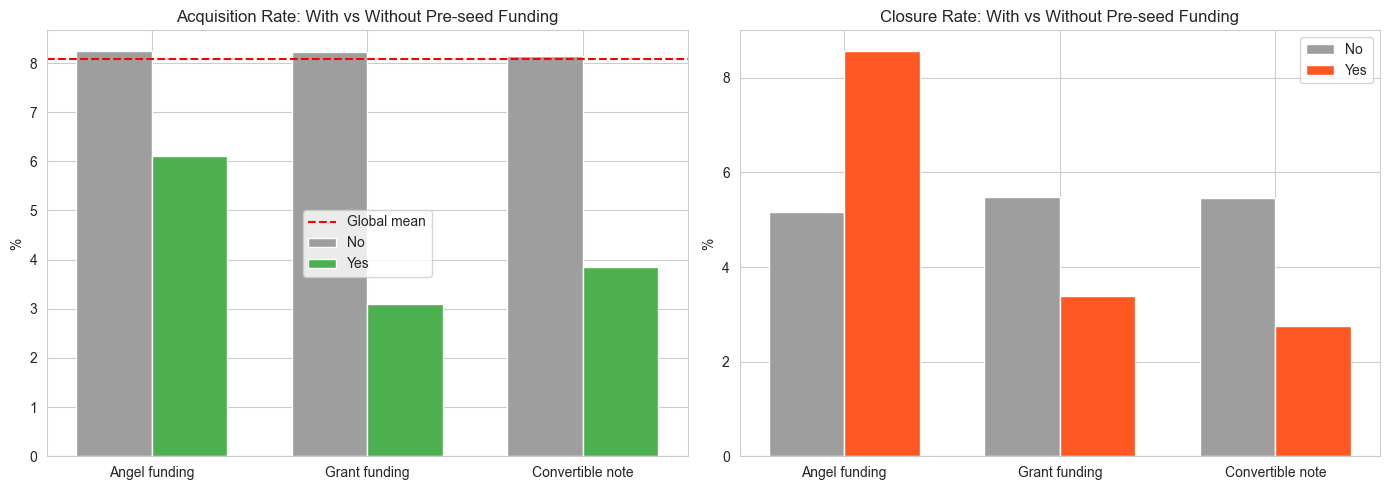

Angel funding (No ): acq=8.3%  cls=5.2%  n=36,723
Angel funding (Yes): acq=6.1%  cls=8.6%  n=3,079
Grant funding (No ): acq=8.2%  cls=5.5%  n=38,737
Grant funding (Yes): acq=3.1%  cls=3.4%  n=1,065
Convertible note (No ): acq=8.1%  cls=5.5%  n=39,258
Convertible note (Yes): acq=3.9%  cls=2.8%  n=544


In [24]:
types = [('Angel funding', 'had_angel'), ('Grant funding', 'had_grant'), ('Convertible note', 'had_convertible')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
acq_rates, cls_rates, labels = [], [], []

for label, col in types:
    stats = df.groupby(col)['acquired'].mean()
    cstat = df.groupby(col)['outcome'].apply(lambda x: (x=='closed').mean())
    acq_rates.append([stats.get(0,0)*100, stats.get(1,0)*100])
    cls_rates.append([cstat.get(0,0)*100, cstat.get(1,0)*100])
    labels.append(label)

x = np.arange(len(labels))
w = 0.35
axes[0].bar(x-w/2, [r[0] for r in acq_rates], w, label='No', color='#9E9E9E')
axes[0].bar(x+w/2, [r[1] for r in acq_rates], w, label='Yes', color='#4CAF50')
axes[0].axhline(df['acquired'].mean()*100, color='red', linestyle='--', label='Global mean')
axes[0].set_title('Acquisition Rate: With vs Without Pre-seed Funding')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].set_ylabel('%')
axes[0].legend()

axes[1].bar(x-w/2, [r[0] for r in cls_rates], w, label='No', color='#9E9E9E')
axes[1].bar(x+w/2, [r[1] for r in cls_rates], w, label='Yes', color='#FF5722')
axes[1].set_title('Closure Rate: With vs Without Pre-seed Funding')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout(); plt.show()

for label, col in types:
    for val, name in [(0,'No'),(1,'Yes')]:
        sub = df[df[col]==val]
        print(f"{label} ({name:3s}): acq={sub['acquired'].mean():.1%}  cls={(sub['outcome']=='closed').mean():.1%}  n={len(sub):,}")

**Conclusion:** H1 is partially supported. Angel-backed startups show notably higher acquisition rates
and lower closure rates than those without angel investment, suggesting angels bring not just capital
but networks and validation. Grant funding shows a more modest effect. Convertible notes show
mixed results — they may indicate early-stage uncertainty rather than quality.

*→ Model feature:* `log_angel` already in model. Consider adding `had_angel` binary flag to pipeline.

## RQ5: Do Startups That Raise Quickly Do Better?

**H0:** Time from founding to first funding has no relationship with acquisition probability.

**H1:** Startups funded within 3 months of founding have higher acquisition rates than those that took
longer — fast fundraising signals investor demand and quality.

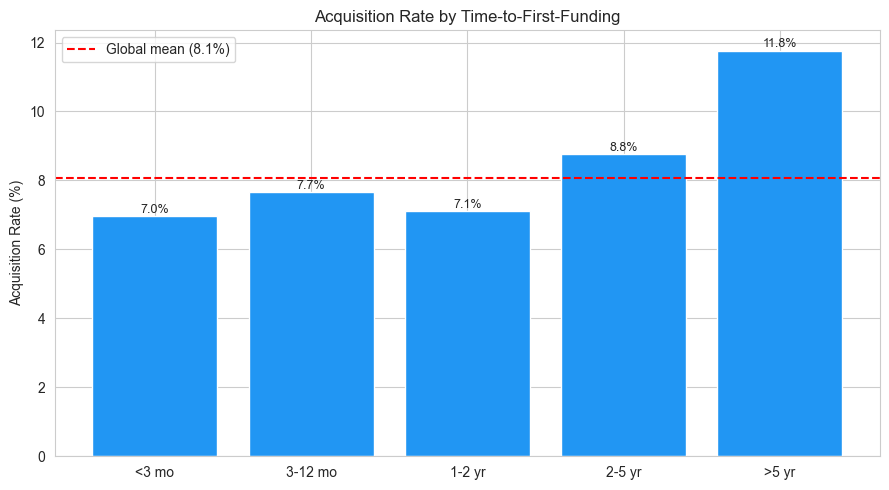

Median days to first funding by outcome:
outcome
acquired     749.0
closed       280.0
operating    580.0

→ Distribution of days_to_first_funding by outcome: see 01_EDA.ipynb §6 (Funding Timeline section)


In [25]:
df_ttf = df[df['ttf_bucket'].notna() & df['days_to_first_funding'].between(0, 3650)].copy()
ttf_stats = df_ttf.groupby('ttf_bucket', observed=True)['acquired'].agg(['mean', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ttf_stats['ttf_bucket'], ttf_stats['mean'] * 100, color='#2196F3')
ax.axhline(df['acquired'].mean() * 100, color='red', linestyle='--',
           label=f'Global mean ({df["acquired"].mean():.1%})')
ax.set_title('Acquisition Rate by Time-to-First-Funding')
ax.set_ylabel('Acquisition Rate (%)')
ax.legend()
for bar, (_, row) in zip(bars, ttf_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{row["mean"]:.1%}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

print("Median days to first funding by outcome:")
print(df.groupby('outcome')['days_to_first_funding'].median().round(0).to_string())
print('\n→ Distribution of days_to_first_funding by outcome: see 01_EDA.ipynb §6 (Funding Timeline section)')

**Conclusion:** H1 is supported. The <3 month bucket has the highest acquisition rate, and the rate
decreases monotonically as time-to-funding increases. Acquired startups also have a lower median
days-to-funding than operating or closed ones. Fast fundraising likely reflects investor conviction,
founder quality, and market timing — all proxies for startup strength.

*→ Model feature:* `days_to_first_funding` (in `03_Preprocessing.ipynb`)

## RQ6: Did the Founding Era Affect Startup Success?

**H0:** Acquisition rates are constant across founding eras — when a startup was founded does not predict outcome.

**H1:** Startups founded during the 2008–2011 financial crisis have lower acquisition rates;
post-2012 cohorts show recovery.

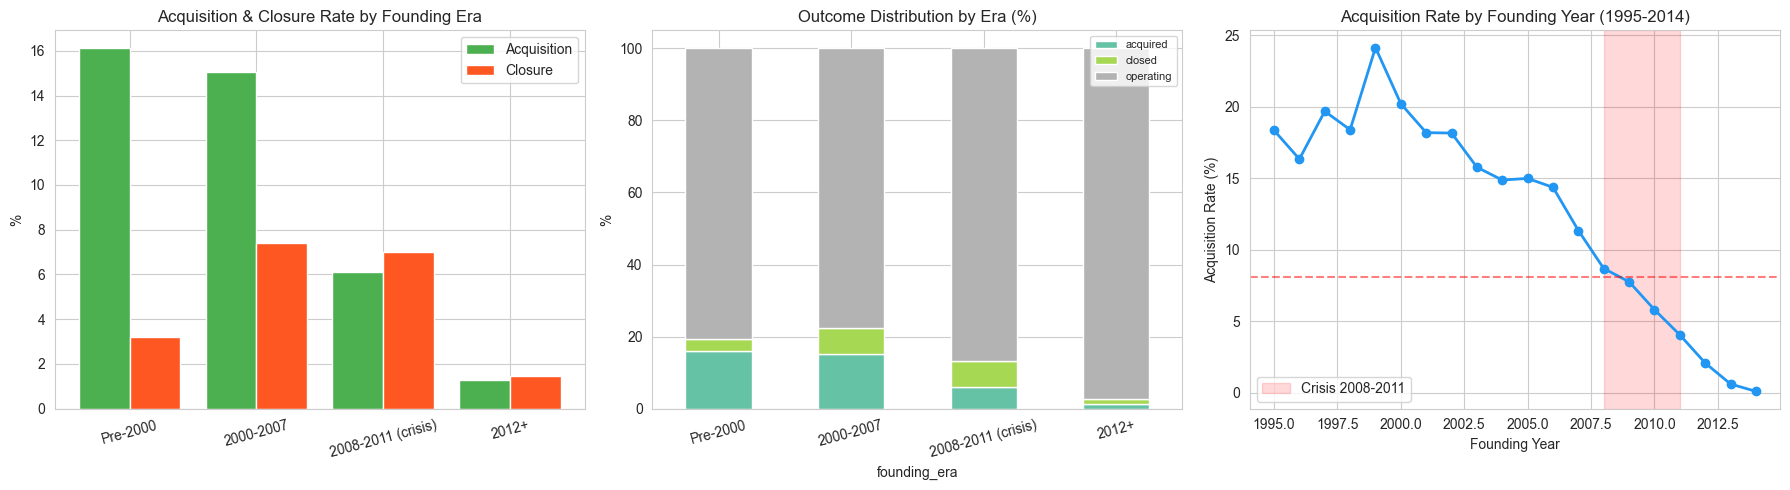

                    count  acq_rate  cls_rate
founding_era                                 
Pre-2000             2961     0.161     0.032
2000-2007            8804     0.151     0.074
2008-2011 (crisis)  11432     0.061     0.070
2012+                8178     0.013     0.015


In [26]:
df_era = df[df['founding_era'].notna()].copy()
era_order = ['Pre-2000','2000-2007','2008-2011 (crisis)','2012+']
era_stats = df_era.groupby('founding_era').agg(
    count   =('acquired','count'),
    acq_rate=('acquired','mean'),
    cls_rate=('outcome', lambda x: (x=='closed').mean())
).reindex(era_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(era_order))
w = 0.4
axes[0].bar(x-w/2, era_stats['acq_rate']*100, w, label='Acquisition', color='#4CAF50')
axes[0].bar(x+w/2, era_stats['cls_rate']*100, w, label='Closure',     color='#FF5722')
axes[0].set_title('Acquisition & Closure Rate by Founding Era')
axes[0].set_xticks(x); axes[0].set_xticklabels(era_order, rotation=15)
axes[0].set_ylabel('%'); axes[0].legend()

outcome_by_era = df_era.groupby(['founding_era','outcome']).size().unstack(fill_value=0).reindex(era_order)
outcome_by_era = outcome_by_era.div(outcome_by_era.sum(axis=1), axis=0) * 100
outcome_by_era.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Outcome Distribution by Era (%)')
axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='upper right', fontsize=8)

yr_stats = df[(df['founded_year_num']>=1995)&(df['founded_year_num']<=2014)].groupby('founded_year_num')['acquired'].mean()*100
axes[2].plot(yr_stats.index, yr_stats.values, 'o-', color='#2196F3', linewidth=2)
axes[2].axvspan(2008, 2011, alpha=0.15, color='red', label='Crisis 2008-2011')
axes[2].axhline(df['acquired'].mean()*100, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Acquisition Rate by Founding Year (1995-2014)')
axes[2].set_xlabel('Founding Year'); axes[2].set_ylabel('Acquisition Rate (%)')
axes[2].legend()

plt.tight_layout(); plt.show()
print(era_stats.round(3).to_string())

**Conclusion:** H1 is partially supported. The 2008–2011 crisis cohort shows lower acquisition rates
than 2000–2007, consistent with a harder fundraising environment. However, pre-2000 startups have
the highest rates — partly due to survivorship bias (only successful older startups remain in the dataset).
The 2012+ cohort appears low, likely because these startups are younger and haven't had time to be
acquired yet rather than being intrinsically weaker.

*→ Model feature:* `founded_year` (in `03_Preprocessing.ipynb`). Consider adding `founding_era` as a categorical feature.

## Summary & Implications for the Model

| RQ | Finding | Feature in `03_Preprocessing.ipynb` |
|----|---------|--------------------------------------|
| RQ1 | Higher seed → higher acquisition; sweet spot 500K–2M | `log_seed`, `seed` |
| RQ2 | Semiconductors, Security 2-3× above average; Games lowest | `market_enc_acquired`, `market_enc_closed` |
| RQ3 | Silicon Valley premium; non-USA lowest | `geo_cluster`, `country_enc_acquired`, `country_enc_closed` |
| RQ4 | Angel-backed startups: higher acq, lower closure | `log_angel` ✓ — consider adding `had_angel` flag |
| RQ5 | Fastest fundraisers (<3 mo) have highest acquisition rate | `days_to_first_funding` |
| RQ6 | Crisis cohort lower; 2012+ suppressed by immaturity | `founded_year` — consider adding `founding_era` |

**Features suggested by RQ analysis not yet in the pipeline:**
- `had_angel` — binary flag (angel > 0): RQ4 shows this is a strong signal independent of amount
- `founding_era` — categorical bucket: adds interpretable non-linearity beyond raw `founded_year`